In [6]:
import os
import sys
from pathlib import Path

import numpy as np

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

from docs.plot_setup import set_professional_style
plt = set_professional_style()

import SysSimX

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from fem_pendulum import FEMPendulum
import pendulum_config as config

---------------------

**Instantaite FEM Pendulum and Adapt Configurations**

In [2]:
model = FEMPendulum(name="FEM_Pendulum", group="Plant")

mesh_params = config.MeshParameters()
mesh_params.max_element_size = 0.1 / 6

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 20  # Initial angle
q0 = np.deg2rad(init_params.angular_position_deg)
init_params.drive_torque = 0 # Nm

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3  # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 7800  # Density for the pendulum

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1
sim_params.with_contact = True
sim_params.use_gravity = True

contact_params = config.ContactParameters()
contact_params.kn = 1e10

anim_params = config.AnimationParameters()
anim_params.animate = False

model.set_parameters(
    mat_params=mat_params,
    contact_params=contact_params,
    init_params=init_params,
    sim_params=sim_params,
    anim_params=anim_params,
    mesh_params=mesh_params
)

model.initialize(0.0)
model.setup_monitoring()
model.display_monitoring()
model.initialize_scene()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [3]:
model.do_step(0, model.sim_params.t_end)

In [4]:
history = model.get_history()
t_vals = history['q']['time']
q_vals = history['q']['values']
omega_vals = history['omega']['values']
alpha_vals = history['alpha']['values']

In [10]:
# Theoretical maximum angular velocity at impact (no losses)
g = 9.81
L = model._equivalent_length
m = model.mass
I = model.inertia
q0 = np.deg2rad(20)

omega_max = np.sqrt(2 * m * g * L * (1 - np.cos(q0)) / I)

print(f"Theoretical maximum angular velocity at impact (no losses): {omega_max:.2f} rad/s")

Theoretical maximum angular velocity at impact (no losses): 1.26 rad/s


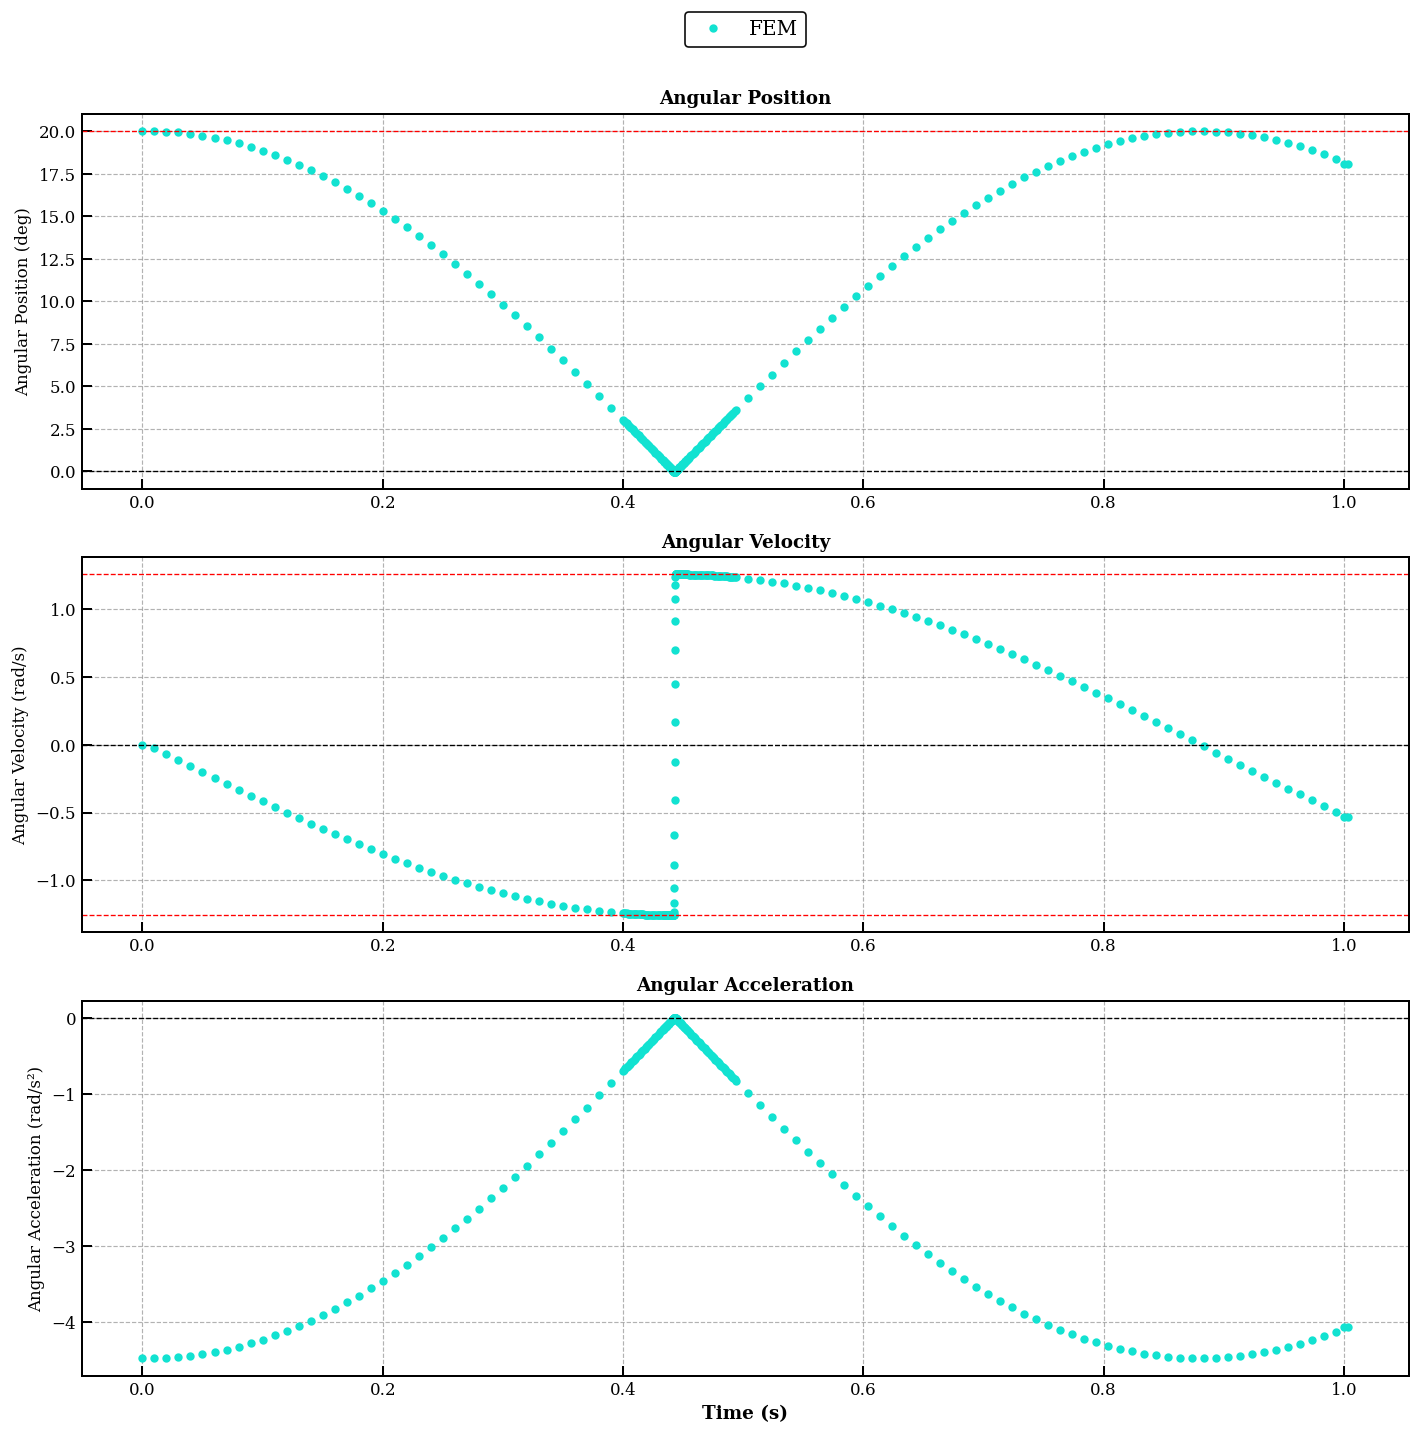

In [17]:
marker_size = 4
fem_style = {'color': "#12e2d1", 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size, 'linewidth': 3.5}  
opensim_style = {'color': "#f8c20f", 'linestyle': 'None', 'marker': 's', 'markersize': marker_size, 'linewidth': 3.5} 
eqb_style = {'color': "#1d8d43", 'linestyle': 'None', 'marker': '^', 'markersize': marker_size, 'linewidth': 3.5}
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

plt.figure(figsize=(12, 12))

plt.subplot(3,1,1).set_title("Angular Position", **fontdict)
plt.plot(t_vals, np.rad2deg(q_vals), label="FEM", **fem_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.axhline(init_params.angular_position_deg, color='red', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Position (deg)")
plt.grid(which='both')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)

plt.subplot(3,1,2).set_title("Angular Velocity", **fontdict)
plt.plot(t_vals, omega_vals, label="FEM", **fem_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.axhline(omega_max, color='red', linestyle='--', linewidth=0.8)
plt.axhline(-omega_max, color='red', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Velocity (rad/s)")
plt.grid(which='both')

plt.subplot(3,1,3).set_title("Angular Acceleration", **fontdict)
plt.plot(t_vals, alpha_vals, label="FEM", **fem_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which='both')

plt.xlabel("Time (s)", **fontdict)
plt.tight_layout()
plt.savefig("../figures/StateSynchronization_impact.svg")
plt.show()

In [16]:
alpha_vals

array([-4.48271923e+00, -4.48133938e+00, -4.47582111e+00, -4.46478868e+00,
       -4.44825033e+00, -4.42621850e+00, -4.39870989e+00, -4.36574558e+00,
       -4.32735120e+00, -4.28355699e+00, -4.23439810e+00, -4.17991466e+00,
       -4.12015210e+00, -4.05516129e+00, -3.98499881e+00, -3.90972715e+00,
       -3.82941504e+00, -3.74413753e+00, -3.65397639e+00, -3.55902019e+00,
       -3.45936461e+00, -3.35511255e+00, -3.24637436e+00, -3.13326793e+00,
       -3.01591886e+00, -2.89446047e+00, -2.76903392e+00, -2.63978815e+00,
       -2.50687991e+00, -2.37047361e+00, -2.23074129e+00, -2.08786236e+00,
       -1.94202347e+00, -1.79341816e+00, -1.64224668e+00, -1.48871547e+00,
       -1.33303695e+00, -1.17542891e+00, -1.01611419e+00, -8.55320005e-01,
       -6.93277566e-01, -6.77011740e-01, -6.60736005e-01, -6.44450600e-01,
       -6.28155761e-01, -6.11851725e-01, -5.95538728e-01, -5.79217009e-01,
       -5.62886806e-01, -5.46548356e-01, -5.30201898e-01, -5.13847670e-01,
       -4.97485910e-01, -

In [15]:
maximum_alpha = np.max(alpha_vals)
print(f"Maximum angular acceleration during simulation: {maximum_alpha:.2f} rad/s²")

Maximum angular acceleration during simulation: 0.01 rad/s²
